In [11]:
#Cek dataset
from glob import glob

path = r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\BreaKHis_v1\BreaKHis_v1\histology_slides\breast"

files = glob(f"{path}/**/*.png", recursive=True)

print(len(files))

7909


In [15]:
#Label Mapping 
import os
import shutil
from glob import glob

# ======================
# PATH
# ======================
BREAKHIS_PATH = r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\BreaKHis_v1\BreaKHis_v1\histology_slides\breast"

OUTPUT = "data_breakhis_mapped"

# ======================
# CREATE FOLDER
# ======================
os.makedirs(os.path.join(OUTPUT, "benign"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT, "malignant"), exist_ok=True)

# ======================
# AMBIL DATA (200X & 400X)
# ======================
benign = (
    glob(os.path.join(BREAKHIS_PATH, "benign/***/**/200x/*.png"), recursive=True) +
    glob(os.path.join(BREAKHIS_PATH, "benign/***/**/400x/*.png"), recursive=True)
)

malignant = (
    glob(os.path.join(BREAKHIS_PATH, "malignant/***/**/200x/*.png"), recursive=True) +
    glob(os.path.join(BREAKHIS_PATH, "malignant/***/**/400x/*.png"), recursive=True)
)

print("Benign:", len(benign))
print("Malignant:", len(malignant))

# ======================
# COPY FUNCTION
# ======================
def copy_files(files, label):
    for i, f in enumerate(files):
        try:
            name = f"{label}_{i}.png"
            dst = os.path.join(OUTPUT, label, name)

            shutil.copy2(f, dst)

            if i % 500 == 0:
                print(f"{label}: {i}/{len(files)}")

        except:
            continue

# ======================
# EXECUTE
# ======================
copy_files(benign, "benign")
copy_files(malignant, "malignant")

print("\nBreakHis Mapping DONE ✅")

Benign: 1211
Malignant: 2622
benign: 0/1211
benign: 500/1211
benign: 1000/1211
malignant: 0/2622
malignant: 500/2622
malignant: 1000/2622
malignant: 1500/2622
malignant: 2000/2622
malignant: 2500/2622

BreakHis Mapping DONE ✅


In [2]:
#split
import os
import shutil
import random
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ===============================
# 1. SET PATH
# ===============================
base_dir = r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\data_breakhis_mapped"

train_dir = os.path.join(base_dir, "train")

split_ratio = (1)
target_per_class = 1000

valid_ext = [".jpg", ".jpeg", ".png"]

# ===============================
# 2. CLEANING FUNCTION
# ===============================
def is_valid_image(path):
    try:
        img = cv2.imread(path)
        return img is not None
    except:
        return False

# ===============================
# 3. SPLIT + BALANCE
# ===============================
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

for class_name in classes:

    if class_name in ["train"]:
        continue

    class_path = os.path.join(base_dir, class_name)

    images = [
        f for f in os.listdir(class_path)
        if os.path.splitext(f)[1].lower() in valid_ext
    ]

    # 🔍 Cleaning
    images = [img for img in images if is_valid_image(os.path.join(class_path, img))]

    # 🔥 BALANCING
    if len(images) < target_per_class:
        images = images + random.choices(images, k=target_per_class - len(images))
    else:
        images = random.sample(images, target_per_class)

    random.shuffle(images)

    # 🔀 Split
    n_total = len(images)
    n_train = int(n_total * split_ratio)

    splits = {
        train_dir: images[:n_train],
    }

    for split_dir, split_images in splits.items():

        class_split_path = os.path.join(split_dir, class_name)
        os.makedirs(class_split_path, exist_ok=True)

        for i, img in enumerate(split_images):

            src = os.path.join(class_path, img)
            dst_name = f"{class_name}_{i}.jpg"
            dst = os.path.join(class_split_path, dst_name)

            # Optional augment ringan
            img_data = cv2.imread(src)

            if random.random() > 0.5:
                img_data = cv2.flip(img_data, 1)

            cv2.imwrite(dst, img_data)

print("✅ SPLIT + BALANCE + CLEANING SELESAI")


✅ SPLIT + BALANCE + CLEANING SELESAI


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import KFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from PIL import Image

# ==========================
# 1. PARAMETER
# ==========================

IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 20
K_FOLDS    = 5
LR         = 0.0001
DATASET_PATH = r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\Fixed\train"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# ==========================
# 2. DATASET & TRANSFORM
# ==========================

# Transform untuk training (augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, shear=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Transform untuk validasi/test (tanpa augmentasi)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load seluruh dataset tanpa splitting
# K-Fold akan membagi sendiri secara otomatis
full_dataset_train = ImageFolder(root=DATASET_PATH, transform=train_transform)
full_dataset_val   = ImageFolder(root=DATASET_PATH, transform=val_transform)

print(f"Total data   : {len(full_dataset_train)}")
print(f"Kelas        : {full_dataset_train.classes}")
print(f"Jumlah fold  : {K_FOLDS}")

# ==========================
# 3. MODEL
# ==========================

def build_model():
    base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Awalnya freeze semua
    for param in base_model.parameters():
        param.requires_grad = False

    # UNFREEZE layer 4 (lapisan blok terakhir ResNet)
    # Ini sangat krusial untuk meningkatkan akurasi pada dataset kecil/spesifik
    for param in base_model.layer4.parameters():
        param.requires_grad = True-

    in_features = base_model.fc.in_features
    base_model.fc = nn.Sequential(
        nn.Dropout(0.4), # Sedikit turunkan dropout jika underfitting
        nn.Linear(in_features, 512), # Tambah lapisan perantara (optional)
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512, 1),
        nn.Sigmoid()
    )

    return base_model.to(device)

# ==========================
# 4. TRAIN & EVAL FUNCTION
# ==========================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = (outputs > 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds       = (outputs > 0.5).float()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(outputs.cpu().numpy())

    return (total_loss / total, correct / total,
            np.array(all_labels).flatten(),
            np.array(all_preds).flatten(),
            np.array(all_probs).flatten())

# ==========================
# 5. K-FOLD TRAINING
# ==========================

kfold      = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
criterion  = nn.BCELoss()

# Wadah hasil tiap fold
fold_results = {
    "train_loss": [], "val_loss": [],
    "train_acc" : [], "val_acc" : [],
}

all_true_labels = []
all_pred_labels = []
all_pred_probs  = []

print("\n" + "="*60)
print("           MEMULAI K-FOLD CROSS VALIDATION")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(
        kfold.split(np.arange(len(full_dataset_train)))):

    print(f"\n{'─'*60}")
    print(f"  FOLD {fold+1}/{K_FOLDS}")
    print(f"  Train: {len(train_idx)} | Val: {len(val_idx)}")
    print(f"{'─'*60}")

    # ── Sampler per fold ──────────────────────────────────────────────
    train_sampler = SubsetRandomSampler(train_idx)
    val_sampler   = SubsetRandomSampler(val_idx)

    train_loader = DataLoader(full_dataset_train,
                              batch_size=BATCH_SIZE,
                              sampler=train_sampler)
    val_loader   = DataLoader(full_dataset_val,
                              batch_size=BATCH_SIZE,
                              sampler=val_sampler)

    # ── Bangun model baru tiap fold ───────────────────────────────────
    model     = build_model()
    optimizer = optim.Adam(model.fc.parameters(), lr=LR)

    best_val_acc  = 0.0
    patience      = 5
    patience_count= 0
    best_weights  = None

    history = {"train_loss":[], "val_loss":[],
               "train_acc" :[], "val_acc" :[]}

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion)
        val_loss, val_acc, y_true, y_pred, y_prob = evaluate(
            model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_weights   = {k: v.clone()
                              for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping di epoch {epoch+1}")
                break

    # Simpan hasil fold terbaik
    fold_results["train_loss"].append(np.mean(history["train_loss"]))
    fold_results["val_loss"].append(np.mean(history["val_loss"]))
    fold_results["train_acc"].append(np.mean(history["train_acc"]))
    fold_results["val_acc"].append(best_val_acc)

    # Evaluasi akhir fold dengan bobot terbaik
    model.load_state_dict(best_weights)
    _, _, y_true, y_pred, y_prob = evaluate(model, val_loader, criterion)

    all_true_labels.extend(y_true)
    all_pred_labels.extend(y_pred)
    all_pred_probs.extend(y_prob)

    # Simpan model terbaik
    torch.save(best_weights,
               f"best_model_fold{fold+1}.pth")
    print(f"  ✅ Best Val Acc Fold {fold+1}: {best_val_acc:.4f}")

# ==========================
# 6. HASIL K-FOLD
# ==========================

print("\n" + "="*60)
print("           HASIL K-FOLD CROSS VALIDATION")
print("="*60)
for fold in range(K_FOLDS):
    print(f"  Fold {fold+1} | "
          f"Val Acc: {fold_results['val_acc'][fold]:.4f} | "
          f"Val Loss: {fold_results['val_loss'][fold]:.4f}")

print(f"\n  Rata-rata Val Accuracy : "
      f"{np.mean(fold_results['val_acc']):.4f} "
      f"± {np.std(fold_results['val_acc']):.4f}")
print(f"  Rata-rata Val Loss     : "
      f"{np.mean(fold_results['val_loss']):.4f} "
      f"± {np.std(fold_results['val_loss']):.4f}")


Menggunakan device: cuda
Total data   : 2000
Kelas        : ['benign', 'malignant']
Jumlah fold  : 5

           MEMULAI K-FOLD CROSS VALIDATION

────────────────────────────────────────────────────────────
  FOLD 1/5
  Train: 1600 | Val: 400
────────────────────────────────────────────────────────────
  Epoch  1/20 | Train Loss: 0.6050 Acc: 0.6869 | Val Loss: 0.4655 Acc: 0.8100
  Epoch  2/20 | Train Loss: 0.4889 Acc: 0.7831 | Val Loss: 0.4069 Acc: 0.8300
  Epoch  3/20 | Train Loss: 0.4343 Acc: 0.8187 | Val Loss: 0.3435 Acc: 0.8600
  Epoch  4/20 | Train Loss: 0.4010 Acc: 0.8213 | Val Loss: 0.3273 Acc: 0.8625
  Epoch  5/20 | Train Loss: 0.4194 Acc: 0.8125 | Val Loss: 0.3763 Acc: 0.8425
  Epoch  6/20 | Train Loss: 0.3779 Acc: 0.8331 | Val Loss: 0.3100 Acc: 0.8650
  Epoch  7/20 | Train Loss: 0.3964 Acc: 0.8231 | Val Loss: 0.3109 Acc: 0.8600
  Epoch  8/20 | Train Loss: 0.3869 Acc: 0.8250 | Val Loss: 0.3090 Acc: 0.8650
  Epoch  9/20 | Train Loss: 0.4164 Acc: 0.8169 | Val Loss: 0.2941 Acc: 0

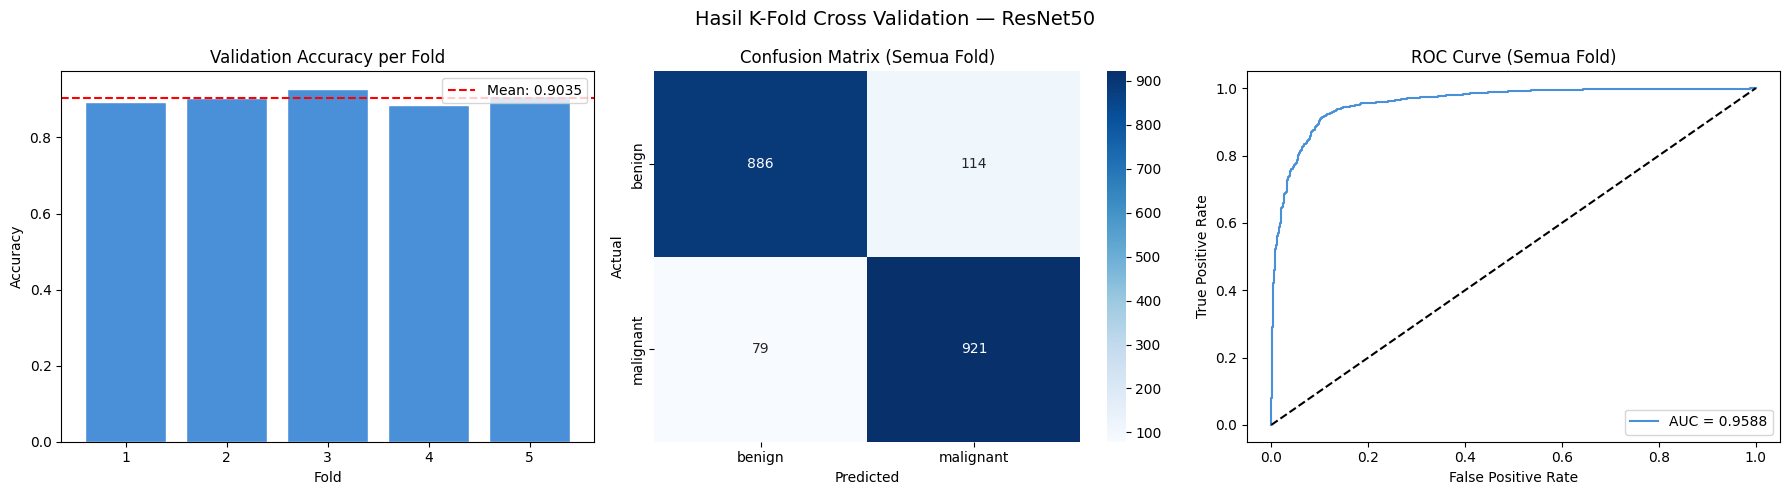


Classification Report (Semua Fold):
              precision    recall  f1-score   support

      benign       0.92      0.89      0.90      1000
   malignant       0.89      0.92      0.91      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



In [7]:

# ==========================
# 7. VISUALISASI
# ==========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hasil K-Fold Cross Validation — ResNet50", fontsize=14)

# ── Grafik akurasi per fold ───────────────────────────────────────────
axes[0].bar(range(1, K_FOLDS+1), fold_results["val_acc"],
            color="#4A90D9", edgecolor="white")
axes[0].axhline(np.mean(fold_results["val_acc"]),
                color="red", linestyle="--",
                label=f"Mean: {np.mean(fold_results['val_acc']):.4f}")
axes[0].set_title("Validation Accuracy per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# ── Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(all_true_labels, all_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=full_dataset_train.classes,
            yticklabels=full_dataset_train.classes)
axes[1].set_title("Confusion Matrix (Semua Fold)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ── ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_true_labels, all_pred_probs)
roc_auc     = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="#4A90D9",
             label=f"AUC = {roc_auc:.4f}")
axes[2].plot([0,1], [0,1], "k--")
axes[2].set_title("ROC Curve (Semua Fold)")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.savefig("hasil_kfold.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Classification Report ─────────────────────────────────────────────
print("\nClassification Report (Semua Fold):")
print(classification_report(all_true_labels, all_pred_labels,
                            target_names=full_dataset_train.classes))



In [8]:
# ==========================
# 8. PREDIKSI GAMBAR BARU
# ==========================

def predict_image(img_path, model_path="best_model_fold1.pth"):
    """Prediksi gambar baru menggunakan model terbaik."""
    # Load model
    model = build_model()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preprocess
    img = Image.open(img_path).convert("RGB")
    img = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = model(img)[0][0].item()

    label = full_dataset_train.classes[1] if prob > 0.5 \
            else full_dataset_train.classes[0]
    conf  = prob if prob > 0.5 else 1 - prob

    print(f"Hasil     : {label}")
    print(f"Confidence: {conf:.4f}")
    return label, conf

# Contoh pakai:
predict_image(r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\test.png")

Hasil     : malignant
Confidence: 0.9171


('malignant', 0.9170790910720825)

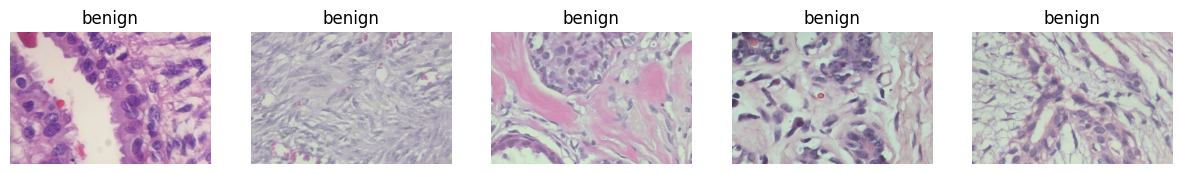

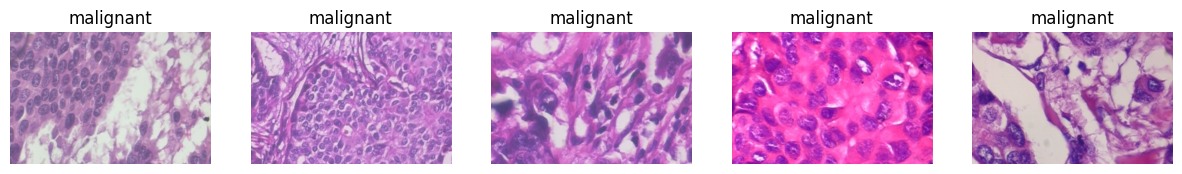

In [9]:
#EDA BREAKHIS
import os
import matplotlib.pyplot as plt
import cv2

def plot_samples(data_path, class_name, n=5):
    path = os.path.join(data_path, class_name)
    images = os.listdir(path)[:n]
    
    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(images):
        img = cv2.imread(os.path.join(path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')
    plt.show()

# Contoh pemanggilan
plot_samples(r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\Fixed\train", 'benign')
plot_samples(r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\Fixed\train", 'malignant')

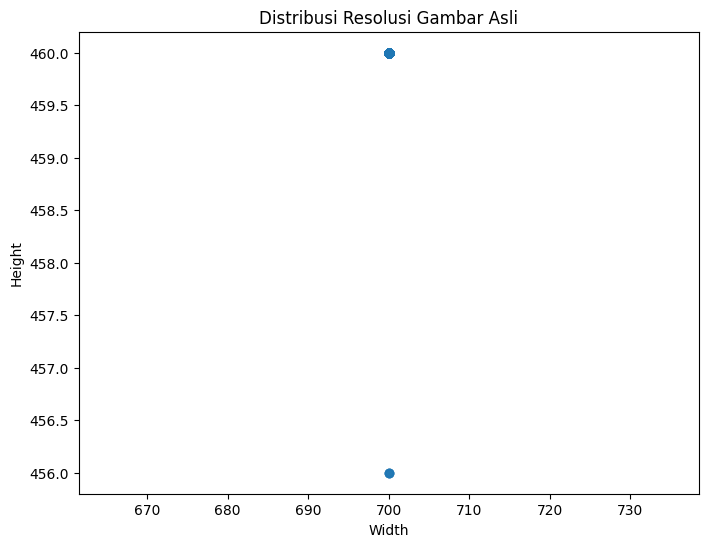

In [15]:
widths, heights = [], []
for class_label in ['benign', 'malignant']:
    path = f'C:/Users/ASUS/Documents/FILE PASCASARJANA/MK_Informatika Biomedik/Kanker Payudara/Fixed/train/{class_label}'
    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribusi Resolusi Gambar Asli')
plt.show()